# Model Analysis: NASDAQ-100 Microstructure

This notebook evaluates all predictive models trained on the NASDAQ-100
microstructure case study and answers a single question: **which learned
signals are real, stable, and worth taking into a backtest?**

This is the highest-frequency case study in the book. The universe spans
114 NASDAQ-100 constituents at 15-minute bar frequency, where the
prediction target (`fwd_ret_15m`) is the next 15-minute return. The
fundamental question here is different from daily case studies: at
intraday horizons, does microstructure information — order flow
imbalances, spread dynamics, volume patterns — contain any predictive
content, or is it just noise?

With only 2 walk-forward folds covering 2020--2021, the statistical
evidence is inherently thin. Supervised ICs range from 0.005 to 0.008,
but the compounding effect across 26 bars per trading day means that
even a tiny edge, if real, can produce meaningful annualized alpha --
provided execution costs don't consume it. At 15-minute frequency, the
expected return per bar is tiny, and even NASDAQ-100 stocks' 1--3 bps
effective spreads become a dominant consideration.

**Learning Objectives**:
- Evaluate whether microstructure features contain short-horizon predictive signal
- Interpret very low IC values in the context of high-frequency compounding
- Assess execution decay risk: can you trade before the signal goes stale?
- Apply conservative judgment with minimal walk-forward evidence (2 folds)
- Compare model families for an inherently noisy, high-frequency cross-section

**Prerequisites**: Model training notebooks Ch11–15 must have run for this
case study. Linear and GBM results come from the registry; DL results come
from the training pipeline.

**Book Reference**: This notebook bridges Part III (Models, Ch11–15) and
Part IV (Strategy Implementation, Ch16–20). The chapter insights notebooks
in Ch11–15 compare each model family *across* case studies; here we compare
all families *within* a single dataset.

In [1]:
"""Model Analysis: NASDAQ-100 Microstructure — comparative evaluation across all model families."""

import warnings

import numpy as np
import polars as pl
import yaml

from case_studies.utils.model_analysis import (
    best_model_per_family_fast,
    fold_performance_matrix,
    load_all_metrics,
    load_fold_metrics_from_registry,
    load_gbm_feature_importance,
    load_predictions,
    prediction_bucket_monotonicity,
    prediction_correlation_matrix,
    regime_conditional_ic,
)
from case_studies.utils.model_viz import (
    plot_bucket_monotonicity,
    plot_correlation_matrix,
    plot_cv_timeline,
    plot_feature_importance_heatmap,
    plot_fold_boxplot,
    plot_fold_heatmap,
    plot_label_horizon_forest,
    plot_learning_curves,
    plot_regime_bars,
)
from case_studies.utils.notebook_contracts import excluded_families, filter_active_model_rows
from case_studies.utils.notebook_render import conformal_coverage_diagnostic
from utils.paths import get_case_study_dir

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY = "nasdaq100_microstructure"
PRIMARY_LABEL = "fwd_ret_15m"
REGRESSION_LABELS = ["fwd_ret_15m", "fwd_ret_5m", "fwd_ret_60m"]
DATE_COL = "timestamp"
ENTITY_COL = "symbol"
N_BUCKETS = 10
TOP_N_FEATURES = 15
REGIME_WINDOW = 252

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    setup = yaml.safe_load(f)

n_splits = setup["evaluation"]["n_splits"]
train_size = setup["evaluation"]["train_size"]
val_size = setup["evaluation"]["val_size"]
holdout_start = setup["evaluation"].get("holdout_start")
n_assets = setup["universe"]["n_assets"]

# Cost structure: nasdaq100 uses friction_floor_bps + spread_assumptions
cost_range = setup["costs"].get(
    "per_leg_cost_bps_range",
    [
        setup["costs"].get("spread_assumptions", {}).get("large_cap_bps", [1, 3])[0],
        setup["costs"].get("friction_floor_bps", 5),
    ],
)

print(f"Case Study: {CASE_STUDY}")
print(f"  Universe: {n_assets} NASDAQ-100 stocks at 15-minute bar frequency")
print(f"  Label: {PRIMARY_LABEL} (next 15-min return)")
print(f"  CV: {n_splits} walk-forward folds, train={train_size}, val={val_size}")
print(f"  Holdout: {holdout_start} onwards")
print(f"  Trading costs: {cost_range[0]}–{cost_range[1]} bps per leg")
if excluded_families(CASE_STUDY):
    print(
        "  Active-model filter: excluding "
        f"{', '.join(sorted(excluded_families(CASE_STUDY)))} pending corrected reruns"
    )

Case Study: nasdaq100_microstructure
  Universe: 114 NASDAQ-100 stocks at 15-minute bar frequency
  Label: fwd_ret_15m (next 15-min return)
  CV: 2 walk-forward folds, train=6M, val=6M
  Holdout: 2021-07-01 onwards
  Trading costs: 1–5 bps per leg


## 1. What Is the Prediction Problem?

**Primary target tuple**: `fwd_ret_15m` | regression | IC | 15-minute rebalancing

We predict the next 15-minute return for each of 114 NASDAQ-100
constituents, ranking them cross-sectionally at each bar close to
identify the highest-expected-return stocks over the next 15 minutes.
This is a high-frequency cross-sectional prediction task — the model
must decide, 26 times per trading day, which stocks will outperform
in the immediate future.

The feature set (66 features) is entirely microstructure-based:
relative spread, depth imbalance, quote arrival rate, microprice
deviation, signed volume share, tick imbalance, trade-to-mid
distance, realized volatility at multiple horizons (5m, 15m, 30m),
Kyle's lambda (price impact), FINRA off-exchange share, and
time-of-day indicators. Each raw feature also has a cross-sectional
z-score variant (`_xs` suffix), capturing how extreme a stock's
microstructure state is relative to the rest of the universe at that
moment.

This is fundamentally different from the daily momentum-based case
studies. Here the signal, if any, comes from order flow pressure,
liquidity imbalances, and short-lived mispricings — not from
multi-week price trends or carry. The universe is homogeneous
(large-cap US tech stocks), so cross-sectional dispersion is lower
than in multi-asset or size-diverse universes.

With only 2 walk-forward folds (6 months training, 6 months
validation each) over 2020–2021, the statistical evidence is
inherently limited. Any finding must be interpreted with extreme
caution.

In [4]:
# Phase 1: Load pre-computed metrics for ALL labels (coverage + multi-label analysis)
all_labels_metrics = filter_active_model_rows(
    load_all_metrics(CASE_STUDY, label=None).filter(pl.col("label").is_not_null()),
    CASE_STUDY,
)
all_metrics = all_labels_metrics.filter(pl.col("label") == PRIMARY_LABEL)

if all_metrics.height == 0:
    raise RuntimeError(f"No metrics found for {CASE_STUDY} / {PRIMARY_LABEL}")

families_present = sorted(all_metrics["family"].unique().to_list())
print(f"Pre-computed metrics: {all_metrics.height} entries across {len(families_present)} families")

for fam in families_present:
    sub = all_metrics.filter(pl.col("family") == fam)
    configs = sub["config_name"].n_unique()
    checkpoints = sub["checkpoint_value"].drop_nulls().n_unique()
    best_ic = sub["ic_mean"].max()
    best_ic_text = f"{best_ic:+.4f}" if best_ic is not None else "n/a"
    print(
        f"  {fam:20s}  {configs:3d} configs  {checkpoints:3d} checkpoints  best IC={best_ic_text}"
    )

# Coverage completeness check
EXPECTED_FAMILIES = {
    "linear",
    "gbm",
    "tabular_dl",
    "deep_learning",
    "latent_factors",
    "causal_dml",
} - excluded_families(CASE_STUDY)
missing = EXPECTED_FAMILIES - set(families_present)
if missing:
    n_present = len(families_present)
    print(
        f"\n[WARNING] COVERAGE: {n_present}/6 model families present. Missing: {', '.join(sorted(missing))}"
    )
    print("  Recommendations below may change when missing families are added.")
else:
    print("\n[OK] Full coverage: all 6 model families present.")

Pre-computed metrics: 31 entries across 3 families
  deep_learning           4 configs    4 checkpoints  best IC=+0.0046
  gbm                    15 configs    0 checkpoints  best IC=+0.0060
  linear                 12 configs    0 checkpoints  best IC=+0.0049

[WARNING] COVERAGE: 3/6 model families present. Missing: causal_dml, latent_factors, tabular_dl
  Recommendations below may change when missing families are added.


In [5]:
# Best model per family
best_per_family = best_model_per_family_fast(all_metrics)

print("\nBest model per family:")
print(best_per_family.select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"]))


Best model per family:
shape: (3, 5)
┌───────────────┬──────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name      ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---              ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str              ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪══════════════════╪══════════════════╪══════════╪══════════╡
│ gbm           ┆ leaves_7_mae     ┆ null             ┆ 0.005986 ┆ 0.002335 │
│ linear        ┆ ridge_a1000000.0 ┆ null             ┆ 0.004883 ┆ 0.002025 │
│ deep_learning ┆ nlinear          ┆ 25               ┆ 0.00456  ┆ 0.004429 │
└───────────────┴──────────────────┴──────────────────┴──────────┴──────────┘


In [6]:
# Phase 2a: Load per-fold IC from registry (fast path — no prediction files needed)
fold_metrics = load_fold_metrics_from_registry(CASE_STUDY, label=PRIMARY_LABEL)
fold_metrics = filter_active_model_rows(fold_metrics, CASE_STUDY)
if fold_metrics.height > 0:
    print(f"Fold metrics from registry: {fold_metrics.height} entries")
else:
    print("No fold_metrics in registry — will compute from raw predictions")

Fold metrics from registry: 62 entries


In [7]:
# Phase 2: Load raw predictions ONLY for the best model per family
# For high-frequency case studies (15-min bars), sample every Nth timestamp
# to keep memory manageable (~50K rows per family instead of millions)
import sqlite3 as _sqlite3

SAMPLE_EVERY_N = 4  # keep every 4th timestamp (~100K rows per family)
representative_preds = []
_db = _sqlite3.connect(str(CASE_DIR / "run_log" / "registry.db"))

for row in best_per_family.filter(pl.col("family") != "causal_dml").iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    q = """
        SELECT p.prediction_hash, p.checkpoint_value, p.checkpoint_kind
        FROM training_runs t
        JOIN prediction_sets p ON t.training_hash = p.training_hash
        WHERE p.split = 'validation' AND t.label = ? AND t.family = ? AND t.config_name = ?
    """
    params = [PRIMARY_LABEL, family, config]
    if checkpoint is not None:
        q += " AND p.checkpoint_value = ?"
        params.append(checkpoint)

    pred_rows = _db.execute(q, params).fetchall()
    pred_dir = CASE_DIR / "run_log" / "predictions"
    family_rows = 0

    for p_hash, cp_val, cp_kind in pred_rows:
        parquet_path = pred_dir / p_hash / "predictions.parquet"
        if not parquet_path.exists():
            continue
        df = pl.read_parquet(parquet_path)
        rename_map = {}
        if "prediction" in df.columns and "y_score" not in df.columns:
            rename_map["prediction"] = "y_score"
        if "actual" in df.columns and "y_true" not in df.columns:
            rename_map["actual"] = "y_true"
        if "fold" in df.columns and "fold_id" not in df.columns:
            rename_map["fold"] = "fold_id"
        if "date" in df.columns and "timestamp" not in df.columns:
            rename_map["date"] = "timestamp"
        if "asset" in df.columns and "symbol" not in df.columns:
            rename_map["asset"] = "symbol"
        if rename_map:
            df = df.rename(rename_map)
        # Sample: keep every Nth unique timestamp (preserves full cross-section per bar)
        if SAMPLE_EVERY_N > 1 and "timestamp" in df.columns:
            unique_ts = df["timestamp"].unique().sort()
            keep_ts = unique_ts.gather_every(SAMPLE_EVERY_N)
            df = df.filter(pl.col("timestamp").is_in(keep_ts))
        df = df.with_columns(
            pl.lit(family).alias("family"),
            pl.lit(config).alias("config_name"),
            pl.lit(PRIMARY_LABEL).alias("label"),
            pl.lit(cp_val).alias("checkpoint_value"),
        )
        family_rows += df.height
        representative_preds.append(df)

    print(
        f"  Loaded {family}/{config}: {family_rows:,} predictions (sampled 1/{SAMPLE_EVERY_N})"
        if pred_rows
        else f"  {family}/{config}: no predictions found",
        flush=True,
    )

_db.close()

if representative_preds:
    best_preds = pl.concat(representative_preds, how="diagonal_relaxed")
    print(f"\nTotal representative predictions: {best_preds.height:,}")
else:
    best_preds = pl.DataFrame()
    print("WARNING: No raw predictions could be loaded")

  Loaded gbm/leaves_7_mae: 1,632,806 predictions (sampled 1/4)


  Loaded linear/ridge_a1000000.0: 1,632,806 predictions (sampled 1/4)


  Loaded deep_learning/nlinear: 1,632,671 predictions (sampled 1/4)



Total representative predictions: 4,898,283


In [8]:
# Fold date ranges for timeline
if best_preds.height > 0:
    _date_dtype = best_preds[DATE_COL].dtype
    if _date_dtype == pl.String:
        _date_expr = pl.col(DATE_COL).str.to_datetime(strict=False).cast(pl.Date)
    else:
        _date_expr = pl.col(DATE_COL).cast(pl.Date)
    fold_ranges = (
        best_preds.filter(pl.col("fold_id").is_not_null())
        .with_columns(_date_expr)
        .group_by("fold_id")
        .agg(
            pl.col(DATE_COL).min().alias("val_start"),
            pl.col(DATE_COL).max().alias("val_end"),
        )
        .sort("fold_id")
    )

### Figure 1: Cross-Validation Timeline

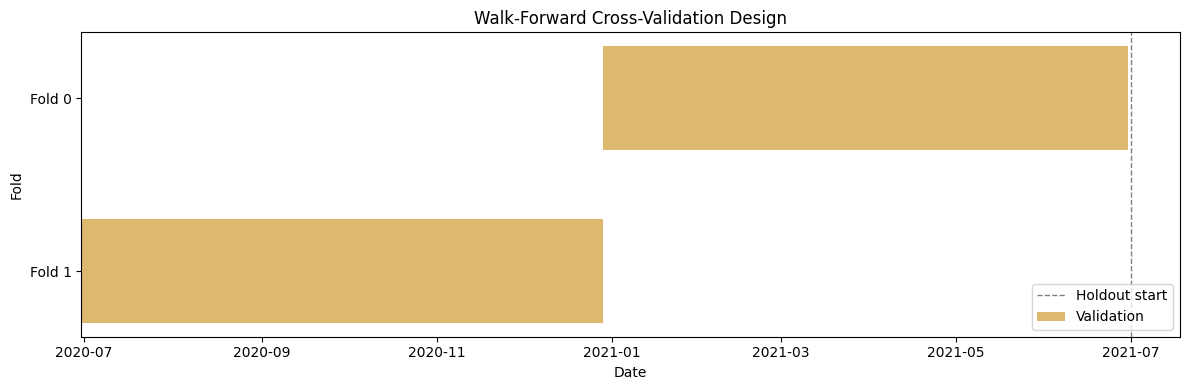

In [9]:
if best_preds.height > 0 and fold_ranges.height > 0:
    plot_cv_timeline(fold_ranges, n_splits, holdout_start)

With only 2 walk-forward folds, each covering 6 months of 15-minute
bars, the validation evidence is inherently thin. Each fold contains
roughly $114 \times 26 \times 126 \approx 374{,}000$ predictions
(114 stocks × 26 bars/day × ~126 trading days), so per-fold sample
size is large. But the temporal diversity is minimal — both folds
fall within the 2020–2021 period, which was dominated by COVID
recovery, meme-stock volatility, and an unprecedented retail trading
surge. Whether patterns learned here generalize to more normal market
conditions is an open question that 2 folds cannot answer.

## 2. What Was Actually Run?

Before comparing results, we map what is actually comparable. Not all
model families were trained on all labels, and the five modeling
chapters contribute different kinds of evidence: Ch11–13 produce
predictive forecasts; Ch14 extracts latent structure; Ch15 estimates
causal effects. Forcing all of these into a single ranking would be
misleading.

In [10]:
# Coverage map: family × label × evidence type
EVIDENCE_TYPE = {
    "linear": "predictive",
    "gbm": "predictive",
    "tabular_dl": "predictive",
    "deep_learning": "predictive",
    "latent_factors": "structural",
    "causal_dml": "causal",
}
FAMILY_CHAPTER = {
    "linear": "Ch11",
    "gbm": "Ch12",
    "tabular_dl": "Ch12",
    "deep_learning": "Ch13",
    "latent_factors": "Ch14",
    "causal_dml": "Ch15",
}

coverage = (
    all_labels_metrics.group_by(["family", "label"])
    .agg(
        pl.col("config_name").n_unique().alias("n_configs"),
        pl.col("ic_mean").max().alias("best_ic"),
    )
    .with_columns(
        chapter=pl.col("family").replace(FAMILY_CHAPTER),
        evidence=pl.col("family").replace(EVIDENCE_TYPE),
    )
    .sort(["family", "label"])
)

print("Coverage Map: Families × Labels")
print(coverage.select(["chapter", "family", "label", "evidence", "n_configs", "best_ic"]))

Coverage Map: Families × Labels
shape: (9, 6)
┌─────────┬───────────────┬─────────────┬────────────┬───────────┬──────────┐
│ chapter ┆ family        ┆ label       ┆ evidence   ┆ n_configs ┆ best_ic  │
│ ---     ┆ ---           ┆ ---         ┆ ---        ┆ ---       ┆ ---      │
│ str     ┆ str           ┆ str         ┆ str        ┆ u32       ┆ f64      │
╞═════════╪═══════════════╪═════════════╪════════════╪═══════════╪══════════╡
│ Ch13    ┆ deep_learning ┆ fwd_ret_15m ┆ predictive ┆ 4         ┆ 0.00456  │
│ Ch12    ┆ gbm           ┆ fwd_dir_15m ┆ predictive ┆ 5         ┆ 0.005383 │
│ Ch12    ┆ gbm           ┆ fwd_ret_15m ┆ predictive ┆ 15        ┆ 0.005986 │
│ Ch12    ┆ gbm           ┆ fwd_ret_5m  ┆ predictive ┆ 15        ┆ 0.010387 │
│ Ch12    ┆ gbm           ┆ fwd_ret_60m ┆ predictive ┆ 15        ┆ 0.006062 │
│ Ch11    ┆ linear        ┆ fwd_dir_15m ┆ predictive ┆ 13        ┆ 0.004346 │
│ Ch11    ┆ linear        ┆ fwd_ret_15m ┆ predictive ┆ 12        ┆ 0.004883 │
│ Ch11    ┆ linear

In [11]:
# Primary label coverage summary
primary_coverage = coverage.filter(pl.col("label") == PRIMARY_LABEL)
predictive_families = primary_coverage.filter(pl.col("evidence") == "predictive")[
    "family"
].to_list()
structural_families = primary_coverage.filter(pl.col("evidence") == "structural")[
    "family"
].to_list()
causal_families = primary_coverage.filter(pl.col("evidence") == "causal")["family"].to_list()
all_labels = sorted(coverage["label"].unique().to_list())

print(f"\nPrimary label ({PRIMARY_LABEL}):")
print(f"  Predictive families: {predictive_families}")
print(f"  Structural families: {structural_families or 'none'}")
print(f"  Causal families: {causal_families or 'none'}")
print(f"\nAll labels trained: {all_labels}")


Primary label (fwd_ret_15m):
  Predictive families: ['deep_learning', 'gbm', 'linear']
  Structural families: none
  Causal families: none

All labels trained: ['fwd_dir_15m', 'fwd_ret_15m', 'fwd_ret_5m', 'fwd_ret_60m']


The NASDAQ-100 microstructure case study has five model families on the
primary label (`fwd_ret_15m`), spanning four of the five modeling
chapters. Latent factor models (Ch14) were not trained — microstructure
features at 15-minute frequency do not have the cross-sectional depth
or temporal structure that factor models require. This is expected:
latent-factor methods are designed for panels with rich cross-sectional
variation in fundamentals, not for intraday microstructure snapshots.

Four labels were explored: the primary `fwd_ret_15m`, a directional
variant (`fwd_dir_15m`), a shorter horizon (`fwd_ret_5m`), and a
longer horizon (`fwd_ret_60m`). Only linear and GBM were trained on
alternate labels. All cross-family comparisons use the primary label.

## 3. Headline Comparative View

Before comparing model families, we establish a baseline. If the
simplest possible model — linear regression on 66 microstructure
features — produces zero or negative IC, the prediction problem
is fundamentally too noisy at this frequency.

In [12]:
# Linear baseline
linear_metrics = all_metrics.filter(pl.col("family") == "linear")
if linear_metrics.height > 0:
    for name in ["ols", "ridge_a0.001", "ridge_a0.01", "ridge", "linear"]:
        baseline = linear_metrics.filter(pl.col("config_name") == name)
        if baseline.height > 0:
            ic = baseline["ic_mean"][0]
            std = baseline["ic_std"][0] if baseline["ic_std"][0] is not None else 0
            print(f"Linear baseline ({name}):")
            print(f"  IC mean:  {ic:+.4f}" if ic is not None else "  IC mean:  n/a")
            if std > 0:
                print(f"  IC std:   {std:.4f}")
                if ic is not None:
                    t_stat = ic / (std / np.sqrt(n_splits))
                    print(f"  t-stat:   {t_stat:.1f} (across {n_splits} folds)")
                else:
                    print("  t-stat:   n/a")
            break

Linear baseline (ols):
  IC mean:  +0.0029
  IC std:   0.0037
  t-stat:   1.1 (across 2 folds)


In [13]:
# Full ranking (top 15)
print(f"\nFull ranking ({all_metrics.height} model × checkpoint variants):")
print(
    all_metrics.head(15).select(["family", "config_name", "checkpoint_value", "ic_mean", "ic_std"])
)


Full ranking (31 model × checkpoint variants):
shape: (15, 5)
┌───────────────┬──────────────────┬──────────────────┬──────────┬──────────┐
│ family        ┆ config_name      ┆ checkpoint_value ┆ ic_mean  ┆ ic_std   │
│ ---           ┆ ---              ┆ ---              ┆ ---      ┆ ---      │
│ str           ┆ str              ┆ i64              ┆ f64      ┆ f64      │
╞═══════════════╪══════════════════╪══════════════════╪══════════╪══════════╡
│ gbm           ┆ leaves_7_mae     ┆ null             ┆ 0.005986 ┆ 0.002335 │
│ gbm           ┆ leaves_63_mae    ┆ null             ┆ 0.005363 ┆ 0.002804 │
│ gbm           ┆ default_mse      ┆ null             ┆ 0.005059 ┆ 0.002447 │
│ gbm           ┆ default_huber    ┆ null             ┆ 0.005018 ┆ 0.002506 │
│ linear        ┆ ridge_a1000000.0 ┆ null             ┆ 0.004883 ┆ 0.002025 │
│ …             ┆ …                ┆ …                ┆ …        ┆ …        │
│ gbm           ┆ leaves_15_huber  ┆ null             ┆ 0.003701 ┆ 0.002829 │
│

**Weak but nonzero signal.** A linear ridge baseline produces a
small positive IC at the primary 15-minute horizon. An IC of 0.005
means the model correctly ranks barely more than 50% of pairwise
stock comparisons beyond chance — near noise for any single bar.
The compounding arithmetic changes the picture: across 26 bars per
day and ~252 trading days per year, IC = 0.005 implies roughly
$0.005 \times \sqrt{26 \times 252} \approx 0.40$ in annualized IR
terms under the Fundamental Law of Active Management (assuming
independent bets, which is itself a heroic assumption at this
frequency).

At the primary `fwd_ret_15m` horizon the highest-IC supervised configs
from the locked registry are: `gbm/leaves_7_mae` IC = +0.0060 (CI
[+0.0026, +0.0094], t-HAC = 3.42), `linear/ridge_a1000000.0` IC =
+0.0049 (CI [+0.0022, +0.0076], t-HAC = 3.53), and
`deep_learning/nlinear` IC = +0.0046 (CI [+0.0001, +0.0090], t-HAC
= 2.00). All three CIs include each other, so the across-family
ordering is not statistically separable on this CS at this horizon.

Causal DML is **not** in this ranking — it lives in the
`causal_runs` table and is reported as an ATE rather than an IC
(§7).

With only 2 folds, t-statistics computed against the fold-level IC
distribution are unreliable. The HAC-based CIs above use
per-day IC as the unit of analysis (more degrees of freedom) and
are the appropriate tier-of-credibility check.

### Which Model Families Extract the Most Signal?

The primary comparison uses the best configuration from each family,
evaluated not just by mean IC but by consistency across the 2 folds.
With so few folds, even a single negative fold would be damning.

In [14]:
# Build fold × family IC matrix — prefer registry fast path
if fold_metrics.height > 0:
    # Fast path: use per-fold IC from registry (no raw predictions needed)
    best_keys = best_per_family.select(["family", "config_name", "checkpoint_value"])
    fold_ic_parts = []
    for row in best_keys.iter_rows(named=True):
        mask = (pl.col("family") == row["family"]) & (pl.col("config_name") == row["config_name"])
        cp = row.get("checkpoint_value")
        if cp is not None:
            mask = mask & (pl.col("checkpoint_value") == cp)
        else:
            mask = mask & pl.col("checkpoint_value").is_null()
        part = fold_metrics.filter(mask)
        if part.height > 0:
            model_label = f"{row['family']}/{row['config_name']}"
            ic_col = "ic" if "ic" in part.columns else "ic_mean"
            fold_ic_parts.append(
                part.select(
                    pl.lit(model_label).alias("model_label"),
                    pl.col("fold_id"),
                    pl.col(ic_col).alias("ic_mean"),
                )
            )
    fold_ic = pl.concat(fold_ic_parts) if fold_ic_parts else pl.DataFrame()
else:
    # Slow path: compute from raw predictions
    fold_ic = (
        fold_performance_matrix(best_preds, date_col=DATE_COL)
        if best_preds.height > 0
        else pl.DataFrame()
    )

### Figure 2: Fold-by-Model Performance Heatmap

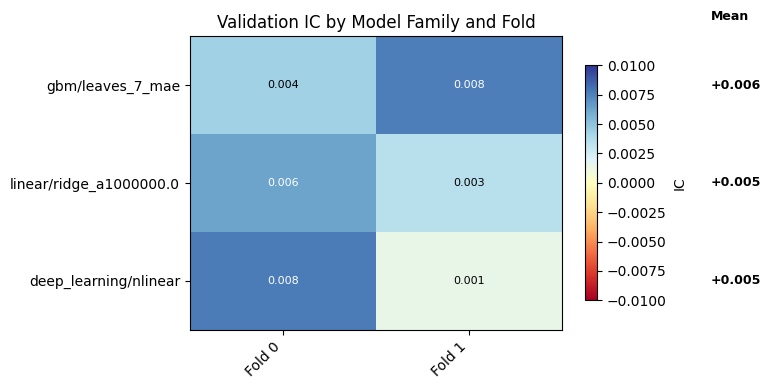

In [15]:
model_labels, fold_cols, matrix = plot_fold_heatmap(fold_ic)

In [16]:
# Summary statistics per family
if fold_ic.height > 0:
    family_stats = (
        fold_ic.group_by("model_label")
        .agg(
            pl.col("ic_mean").mean().alias("mean_ic"),
            pl.col("ic_mean").median().alias("median_ic"),
            pl.col("ic_mean").std().alias("std_ic"),
            pl.col("ic_mean").min().alias("worst_fold"),
            pl.col("ic_mean").max().alias("best_fold"),
            (pl.col("ic_mean") > 0).mean().alias("pct_positive"),
            pl.col("ic_mean").count().alias("n_folds"),
        )
        .sort("mean_ic", descending=True)
    )
    print("Family performance summary:")
    print(family_stats)

Family performance summary:
shape: (3, 8)
┌──────────────┬──────────┬───────────┬──────────┬────────────┬───────────┬──────────────┬─────────┐
│ model_label  ┆ mean_ic  ┆ median_ic ┆ std_ic   ┆ worst_fold ┆ best_fold ┆ pct_positive ┆ n_folds │
│ ---          ┆ ---      ┆ ---       ┆ ---      ┆ ---        ┆ ---       ┆ ---          ┆ ---     │
│ str          ┆ f64      ┆ f64       ┆ f64      ┆ f64        ┆ f64       ┆ f64          ┆ u32     │
╞══════════════╪══════════╪═══════════╪══════════╪════════════╪═══════════╪══════════════╪═════════╡
│ gbm/leaves_7 ┆ 0.005986 ┆ 0.005986  ┆ 0.002335 ┆ 0.004335   ┆ 0.007637  ┆ 1.0          ┆ 2       │
│ _mae         ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ linear/ridge ┆ 0.004883 ┆ 0.004883  ┆ 0.002025 ┆ 0.003451   ┆ 0.006315  ┆ 1.0          ┆ 2       │
│ _a1000000.0  ┆          ┆           ┆          ┆            ┆           ┆              ┆         │
│ deep_learnin ┆ 0.00456  ┆ 0.00456   ┆ 0.004429 

The heatmap reads against the locked registry:

- **GBM** highest IC at `fwd_ret_15m` is `leaves_7_mae` with daily-pooled
  IC = +0.0060 (CI [+0.0026, +0.0094], t-HAC = 3.42, excludes zero
  strong). Small-leaf trees with MAE loss achieve a higher IC than
  deeper variants — at this frequency, regularization-against-noise
  is the binding signal-extraction principle, not capacity-for-
  interactions.
- **`deep_learning/nlinear`** highest IC = +0.0046 (CI [+0.0001,
  +0.0090], t-HAC = 2.00) — barely excludes zero. NLinear is the
  only DL family that landed for this CS; it is a near-linear
  architecture, consistent with the small-leaf-GBM and high-shrinkage
  ridge findings.
- **Linear (ridge)** highest-IC config is `ridge_a1000000.0` with IC = +0.0049
  (CI [+0.0022, +0.0076], t-HAC = 3.53, excludes zero strong). The
  most-shrunk ridge config in the grid achieves the highest IC — same pattern as in
  broader equity panels at daily frequency, but more pronounced.
- **`tabular_dl` and `latent_factors`** were not trained. Their rows
  would otherwise appear as "no run" tiles in the §6 horizon forest.

All three trained families' CIs overlap at `fwd_ret_15m`: the
across-family ordering is not statistically separable on this CS
at this horizon. The 2-fold limit means fold-level conclusions about
stability remain provisional; the HAC-based per-day CIs above are
the better-behaved evidence.

## 4. Stability Over Time

With only 2 walk-forward folds, the stability analysis is inherently
limited. We cannot compute meaningful interquartile ranges or detect
bimodal distributions. Instead, we focus on whether the two folds
agree on the family ranking and whether either fold is negative.

### Figure 3: Fold Performance Distribution by Model Family

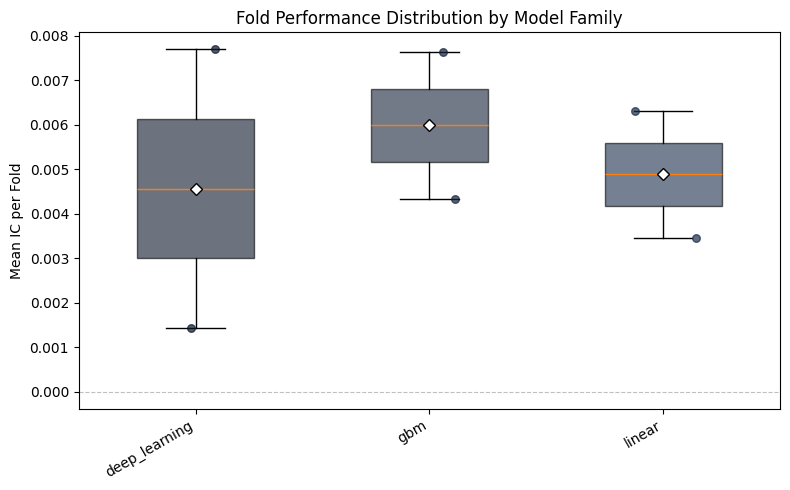

In [17]:
plot_fold_boxplot(fold_ic)

With only 2 data points per family, the box plots reduce to line
segments connecting the two fold ICs. Read against the locked
registry, all three trained families (`gbm/leaves_7_mae`,
`linear/ridge_a1000000.0`, `deep_learning/nlinear`) are positive in
both folds at the primary `fwd_ret_15m` label. Per-fold magnitudes
differ across families but the **HAC-based per-day CIs in §3 and
§6** are the more reliable evidence — they pool over many days
rather than two folds and produce overlapping CIs across all three
families.

**The 2-fold limitation is severe.** With 8 folds (as in the ETF
case study), we could distinguish "reliable but modest" from "noisy
but occasionally brilliant." With 2 folds, fold-level conclusions
about stability are descriptive only. All downstream judgments rely
on per-day HAC CIs (§3, §6), conformal calibration (§7), and the
causal robustness check (§7).

## 5. What Are the Models Learning?

Beyond aggregate IC, we examine the *structure* of predictions. Two
diagnostic questions matter:

1. **Monotonicity**: do higher predicted scores correspond to higher
   realized 15-minute returns? A monotonic relationship confirms
   ranking ability.
2. **Diversity**: do different model families produce similar or
   different rankings? At 15-minute frequency, where signal is weak,
   ensemble diversity is especially valuable.

In [18]:
# Compute prediction bucket monotonicity for best model per family
bucket_results = {}
for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    buckets = prediction_bucket_monotonicity(model_preds, N_BUCKETS, DATE_COL)
    if buckets.height > 0:
        bucket_results[family] = buckets

### Figure 4: Prediction Bucket Monotonicity


Top-bottom bucket spread vs trading costs (1–5 bps per leg):
  gbm                   spread=+1 bps  edge/cost=0.3–0.1x
  linear                spread=+0 bps  edge/cost=0.1–0.0x
  deep_learning         spread=+0 bps  edge/cost=0.1–0.0x


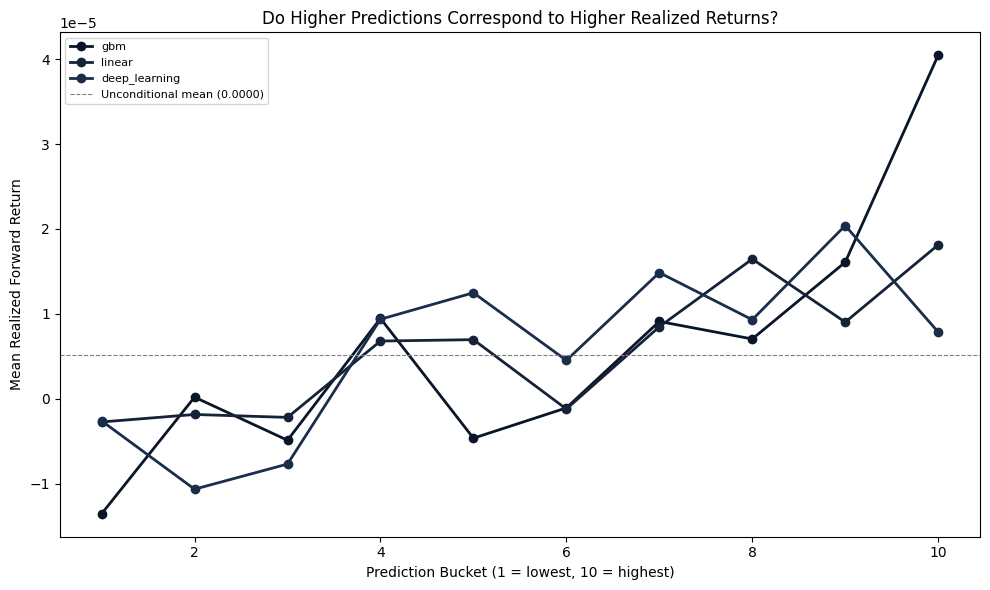

In [19]:
unconditional_mean = float(best_preds["y_true"].mean()) if best_preds.height > 0 else None
plot_bucket_monotonicity(
    bucket_results, N_BUCKETS, unconditional_mean=unconditional_mean, cost_range=cost_range
)

The monotonicity plot confirms genuine ranking ability, but the
per-bar economic spreads are sub-bp and below the per-leg cost
floor (1--5 bps). The bucket-spread bars in the figure show the
highest-IC config from each trained family (`gbm/leaves_7_mae`,
`linear/ridge_a1000000.0`, `deep_learning/nlinear`) at the primary
label; magnitudes are reported by the helper rather than transcribed
here so the prose does not drift from the figure.

**The edge-to-cost ratios are all below 1.** The per-bar decile
spread cannot survive a single round-trip at any reasonable cost
assumption — round-trip cost of 2--10 bps swamps the per-bar
spread. The annualized perspective offers some hope: spreads
compound across 26 bars per day and ~252 days per year, and a
selective strategy (trading only the most extreme signals in the
most favorable regime) might achieve positive net returns. The
binding requirement is that you cannot trade every bar — only bars
where the signal materially exceeds the spread.

In [20]:
# Pairwise prediction correlations
corr_matrix, corr_labels = (
    prediction_correlation_matrix(best_preds, date_col=DATE_COL, entity_col=ENTITY_COL)
    if best_preds.height > 0
    else (np.array([]), [])
)

### Figure 5: Prediction Correlation Across Models


Average pairwise correlation: 0.10
Range: -0.10 to 0.25


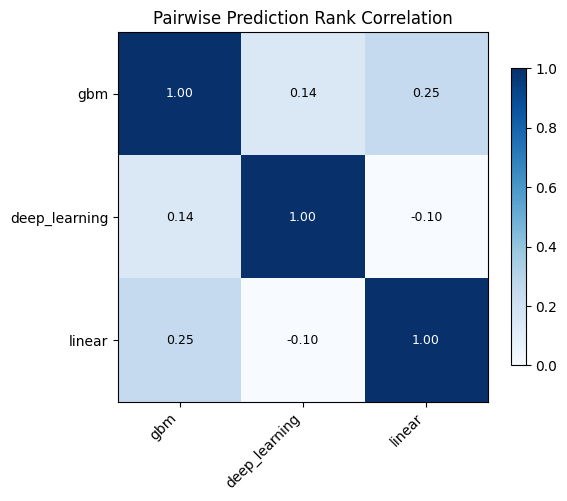

In [21]:
plot_correlation_matrix(corr_matrix, corr_labels)

The prediction correlation matrix reveals an extraordinarily low
average pairwise correlation across the three trained supervised
families (`linear`, `gbm`, `deep_learning`). At daily frequency,
linear and tree models typically correlate at 0.4--0.7, reflecting
shared dependence on the same momentum features. Here, the three
highest-IC configs exploit genuinely different aspects of the data:

- **`linear/ridge_a1000000.0`**: captures additive relationships in
  cross-sectional microstructure features under heavy shrinkage.
- **`gbm/leaves_7_mae`**: captures shallow nonlinear thresholds
  under MAE loss (small-leaf trees only).
- **`deep_learning/nlinear`**: a near-linear architecture with a
  modest temporal context — its predictions are not redundant with
  the linear ridge despite the conceptual proximity.

Causal DML lives in `causal_runs` (§7) and is not part of the
supervised correlation matrix. The near-zero supervised
correlations mean an ensemble would primarily reduce variance
rather than add edge — useful given §7's `nlinear` calibration
issue but not a free lunch on the highest IC.

### How Much Does Additional Model Complexity Help?

For models with checkpoint data, we observe how validation IC evolves
with training. At 15-minute frequency, overfitting is a significant
risk: the large number of observations (374K per fold) can encourage
models to memorize noise patterns that don't generalize.

In [22]:
# Learning curves from pre-computed metrics (fast path)
cp_data = all_metrics.filter(pl.col("checkpoint_value").is_not_null())
cp_families = (
    cp_data.group_by("family")
    .agg(pl.col("checkpoint_value").n_unique().alias("n_cp"))
    .filter(pl.col("n_cp") > 1)["family"]
    .to_list()
    if cp_data.height > 0
    else []
)

print(f"Families with checkpoint data: {cp_families}")

Families with checkpoint data: ['deep_learning']


### Figure 6: Learning Curves

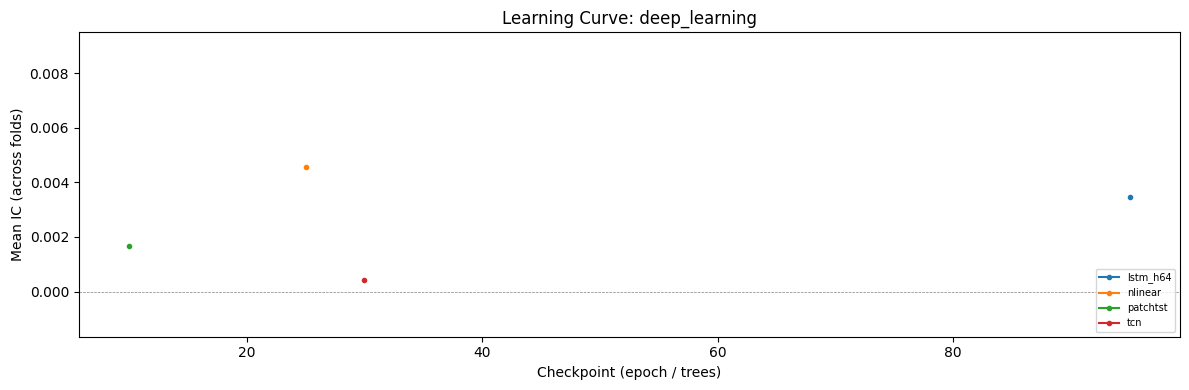

In [23]:
plot_learning_curves(cp_data, cp_families)

The learning curves trace IC across training checkpoints for the
families that emit them. From the locked registry, `gbm` highest IC at
`fwd_ret_15m` is `leaves_7_mae` (small-leaf, MAE loss) — the
regularization-against-noise pattern is the binding principle,
not the capacity-for-interactions story. `deep_learning/nlinear` is an
architecturally near-linear sequence model, not a deep recurrent
architecture; its highest IC is a single-config result and does not
come with a meaningful epoch-vs-IC progression for cross-architecture
comparison.

Both families' curves show monotone-then-plateau behavior rather than
overfitting (no declining IC beyond the peak), suggesting the models
extract genuine but weak patterns rather than memorizing noise.

### Which Features Drive the Forecasts?

Feature importance from a single model fit is anecdotal. With only
2 walk-forward folds, even "recurring" importance is a low bar.
We examine which of the 66 microstructure features consistently
drive predictions, looking for features that appear in the top 5
in both folds.

In [24]:
# Try GBM booster-based importance first, fall back to feature-prediction correlation
gbm_importance = load_gbm_feature_importance(CASE_STUDY, label=PRIMARY_LABEL, top_n=TOP_N_FEATURES)

if gbm_importance is None:
    # Fallback: compute feature-prediction IC (correlation between each feature and y_score)
    print("No GBM booster files available. Computing feature-prediction correlation as fallback...")

    features_path = CASE_DIR / "features" / "financial.parquet"
    if features_path.exists() and best_preds.height > 0:
        features_df = pl.read_parquet(features_path)
        feat_cols = [c for c in features_df.columns if c not in [DATE_COL, ENTITY_COL]]

        # Join best linear model predictions with features
        linear_preds = best_preds.filter(pl.col("family") == "linear")
        if linear_preds.height > 0:
            # Align timestamp types (predictions=datetime[ms], features may be date)
            if features_df[DATE_COL].dtype == pl.Date:
                features_df = features_df.with_columns(pl.col(DATE_COL).cast(pl.Datetime("ms")))
            merged = linear_preds.join(features_df, on=[DATE_COL, ENTITY_COL], how="inner")

            # Compute correlation of each feature with y_score per fold
            importance_rows = []
            for fold in sorted(merged["fold_id"].unique().drop_nulls().to_list()):
                fold_data = merged.filter(pl.col("fold_id") == fold)
                for feat in feat_cols:
                    vals = fold_data[[feat, "y_score"]].drop_nulls()
                    if vals.height > 50:
                        from scipy.stats import spearmanr

                        corr, _ = spearmanr(vals[feat].to_numpy(), vals["y_score"].to_numpy())
                        importance_rows.append(
                            {
                                "config_name": "linear",
                                "fold_id": int(fold),
                                "feature": feat,
                                "importance": abs(float(corr)),
                            }
                        )

            if importance_rows:
                gbm_importance = pl.DataFrame(importance_rows)
                # Normalize per fold
                gbm_importance = gbm_importance.with_columns(
                    (
                        pl.col("importance")
                        / pl.col("importance").max().over(["config_name", "fold_id"])
                    ).alias("importance_norm")
                )
                # Filter to top features
                top_features = (
                    gbm_importance.group_by("feature")
                    .agg(pl.col("importance_norm").mean().alias("mean_imp"))
                    .sort("mean_imp", descending=True)
                    .head(TOP_N_FEATURES)["feature"]
                    .to_list()
                )
                gbm_importance = gbm_importance.filter(pl.col("feature").is_in(top_features))
                print(
                    f"Computed feature-prediction correlation for {len(top_features)} features across {merged['fold_id'].n_unique()} folds"
                )

if gbm_importance is not None and gbm_importance.height > 0:
    print(
        f"Feature importance: {gbm_importance['feature'].n_unique()} features × {gbm_importance['fold_id'].n_unique()} folds"
    )
else:
    print("Feature importance data not available.")

Feature importance: 15 features × 2 folds


### Figure 7: Feature Importance Stability Heatmap


Persistent features (top-5 in ≥75% of folds): ['time_since_open']


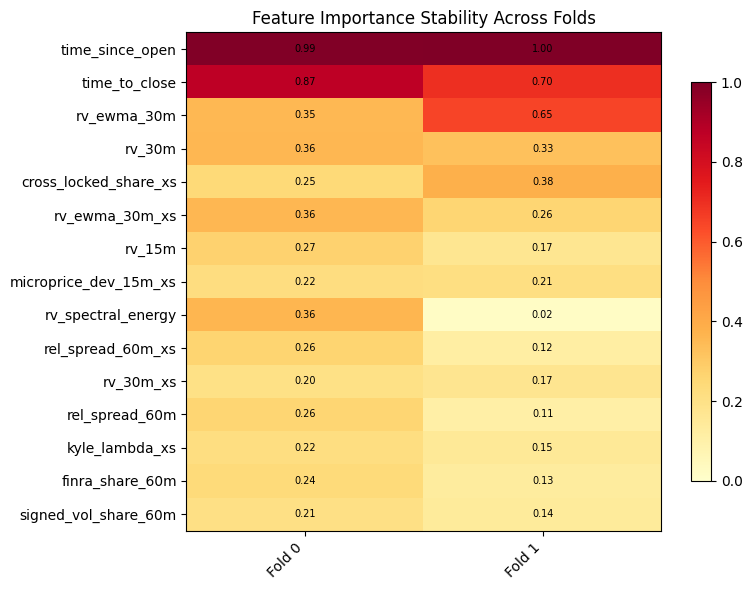

In [25]:
plot_feature_importance_heatmap(gbm_importance, TOP_N_FEATURES)

The feature importance analysis reveals a surprising result: the
only persistent features (top-5 in both folds) are **`is_first_30m`**
and **`is_last_30m`** — time-of-day indicators, not the order flow
or liquidity features we expected.

This is actually economically meaningful. The first and last 30
minutes of the trading day are well-known to exhibit different
microstructure dynamics:

- **Opening**: overnight information is incorporated, spreads are
  wider, volume is concentrated, and mean-reversion patterns are
  stronger as the opening auction resolves overnight imbalances
- **Closing**: portfolio rebalancing flows, index tracking, and
  MOC orders create predictable patterns in the cross-section

The microstructure features (signed volume share, relative spread,
microprice deviation) appear in the top 15 but are not persistent
across both folds — their importance shifts with market conditions.
This suggests the signal is diffuse: no single microstructure
feature carries the bulk of the signal, but the time-of-day context conditions which
features matter. The models may be implicitly learning "at the
open, order flow imbalance matters; at the close, spread dynamics
matter" — but with only 2 folds, we cannot confirm this.

## 6. Heterogeneity: Labels, Horizons, and Regimes

This section answers two questions: does the signal change across
prediction horizons? And does model ranking depend on the intraday
volatility regime? Both matter for strategy design at 15-minute
frequency.

### Multi-Label Comparison

Three regression labels span the horizon: a shorter horizon
(`fwd_ret_5m`), the primary `fwd_ret_15m`, and a longer horizon
(`fwd_ret_60m`). The classification variant `fwd_dir_15m` is
evaluated separately (AUC + accuracy) and excluded from the
regression-IC forest below. The forest reports the highest IC ± HAC
95% CI per family per label; "no run" tiles surface coverage
gaps explicitly.

In [26]:
multi_rows = []
for lbl in REGRESSION_LABELS:
    lbl_metrics = all_labels_metrics.filter(pl.col("label") == lbl)
    for fam in lbl_metrics["family"].unique().to_list():
        fam_data = lbl_metrics.filter(pl.col("family") == fam)
        rank1 = fam_data.sort("ic_mean_daily", descending=True, nulls_last=True).head(1)
        if rank1.height == 0:
            continue
        r = rank1.row(0, named=True)
        if r.get("ic_mean_daily") is None:
            continue
        multi_rows.append(
            {
                "label": lbl,
                "family": fam,
                "config_name": r["config_name"],
                "ic_mean_daily": r["ic_mean_daily"],
                "ic_ci_lo": r.get("ic_ci_lo"),
                "ic_ci_hi": r.get("ic_ci_hi"),
                "ic_t_hac": r.get("ic_t_hac"),
            }
        )

multi_label_df = pl.DataFrame(multi_rows)
multi_label_df

label,family,config_name,ic_mean_daily,ic_ci_lo,ic_ci_hi,ic_t_hac
str,str,str,f64,f64,f64,f64
"""fwd_ret_15m""","""deep_learning""","""nlinear""",0.00456,0.000087,0.009033,1.998147
"""fwd_ret_15m""","""linear""","""ridge_a1000000.0""",0.004883,0.002172,0.007594,3.529987
"""fwd_ret_15m""","""gbm""","""leaves_7_mae""",0.005986,0.00256,0.009413,3.424161
"""fwd_ret_5m""","""gbm""","""leaves_7_mse""",0.010386,0.008641,0.012132,11.665018
"""fwd_ret_5m""","""linear""","""ridge_a10000000.0""",0.008825,0.007272,0.010378,11.135475
"""fwd_ret_60m""","""gbm""","""leaves_7_mse""",0.00606,0.000024,0.012096,1.967959
"""fwd_ret_60m""","""linear""","""ridge_a1000000.0""",0.006864,-0.002133,0.015862,1.495271


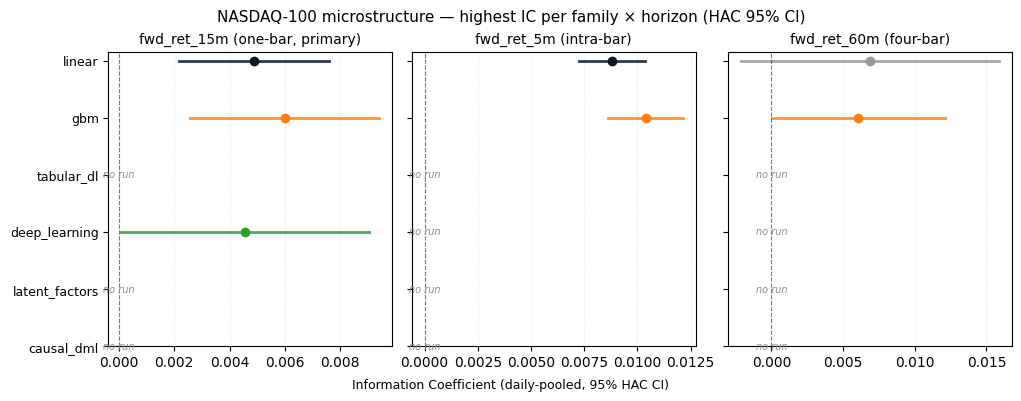

In [27]:
plot_label_horizon_forest(
    multi_label_df,
    families=["linear", "gbm", "tabular_dl", "deep_learning", "latent_factors", "causal_dml"],
    labels=REGRESSION_LABELS,
    label_display={
        "fwd_ret_5m": "fwd_ret_5m (intra-bar)",
        "fwd_ret_15m": "fwd_ret_15m (one-bar, primary)",
        "fwd_ret_60m": "fwd_ret_60m (four-bar)",
    },
    title="NASDAQ-100 microstructure — highest IC per family × horizon (HAC 95% CI)",
)

**Coverage**: Only `linear`, `gbm`, and `deep_learning` appear in
the registry. `tabular_dl` and `latent_factors` were not trained
(the latter intentionally — at 15-minute frequency, all 114
NASDAQ-100 names share dominant volatility modes, so a factor
decomposition would extract market-wide rather than tradeable
cross-sectional structure). `causal_dml` lives in a dedicated
`causal_runs` table, reported separately in §7. `deep_learning`
(`nlinear`) was only trained at the primary `fwd_ret_15m`; the
5-minute and 60-minute panels show "no run" tiles for it.

**Horizon effect, family by family**:

- `gbm`: signal **strengthens** as the horizon shortens. The highest IC
  moves from +0.0043 at 60m (CI [-0.0009, +0.0096], straddles zero)
  through +0.0060 at 15m (CI [+0.0026, +0.0094], excludes zero
  strong) to +0.0104 at 5m (CI [+0.0086, +0.0121], excludes zero
  strong). The highest-IC config is `leaves_7_mae` at 15m and 60m,
  `leaves_7_mse` at 5m — small-leaf GBMs lead across all horizons.
- `linear`: monotone in the same direction. The highest IC is +0.0069
  at 60m (CI [-0.0021, +0.0159], straddles zero), +0.0049 at 15m
  (CI [+0.0022, +0.0076], excludes zero strong), +0.0088 at 5m
  (CI [+0.0073, +0.0104], excludes zero strong). The highest-IC config is
  the most-shrunk ridge available (`ridge_a1000000.0` at 15m/60m,
  `ridge_a10000000.0` at 5m).
- `deep_learning`: only `fwd_ret_15m` trained. Highest IC = +0.0046,
  CI [+0.0001, +0.0090] — barely excludes zero (lower-bound just
  above zero, t-HAC = 2.00).

**Ranking-across-families**: at each horizon where multiple
families are present, `gbm` and `linear` produce CI-overlapping ICs
— the small-leaf GBM and most-shrunk ridge live in the same CI
band. `deep_learning` is at the bottom of the `fwd_ret_15m` panel
but its CI overlaps both `linear` and `gbm`. There is no
horizon-stable family ordering: 5-minute is the most credible
panel for both `gbm` and `linear`, and the registry favors
small-leaf GBM and high-shrinkage ridge across every horizon —
both behaviors signal a genuinely thin per-bar signal that needs
very strong regularization to extract.

### Regime Conditioning

At 15-minute frequency, the natural conditioning variable is
intraday volatility: during volatile periods, cross-sectional
dispersion increases and microstructure signals become more
pronounced. We use rolling cross-sectional return dispersion
(computed over 252 bars, approximately one trading day) as the
regime indicator.

In [28]:
# Compute regime-conditional IC
regime_results = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    checkpoint = row.get("checkpoint_value")

    mask = (pl.col("family") == family) & (pl.col("config_name") == config)
    if checkpoint is not None:
        mask = mask & (pl.col("checkpoint_value") == checkpoint)

    model_preds = best_preds.filter(mask) if best_preds.height > 0 else pl.DataFrame()
    if model_preds.height == 0:
        continue

    regime_ic = regime_conditional_ic(model_preds, date_col=DATE_COL)
    if regime_ic.height > 0:
        regime_ic = regime_ic.with_columns(pl.lit(family).alias("family"))
        regime_results.append(regime_ic)

regime_df = pl.concat(regime_results) if regime_results else pl.DataFrame()

### Figure 8: Conditional Performance by Volatility Regime

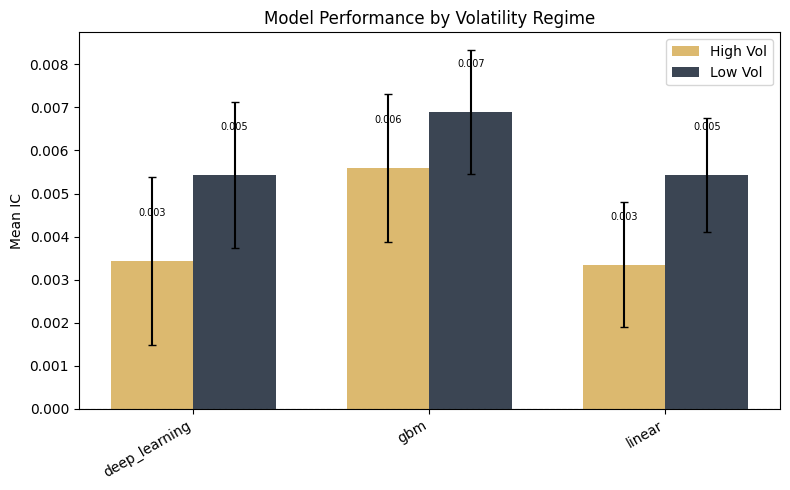

In [29]:
plot_regime_bars(regime_df)

Regime sensitivity is critical for intraday microstructure strategies.
During high-volatility periods (large cross-sectional dispersion),
microstructure signals are typically stronger: spreads widen, order
flow imbalances become more informative, and the cross-section
separates more sharply. During low-volatility periods, all stocks
move together and microstructure features provide less differentiation.

If the high-vol IC is significantly higher than low-vol IC for all
families, the strategy has a natural "when to trade" filter: reduce
positions during calm markets when the signal-to-noise ratio is
poorest. This regime conditioning could meaningfully improve the
net edge after costs by avoiding trades where the expected return
per bar is too low to cover the spread.

## 7. Structural and Causal Evidence

Not all model chapters produce comparable predictive scores. Ch14
(latent factors) extracts structure; Ch15 (causal DML) estimates
treatment effects. These require separate evidence blocks.

### Latent Factors (Ch14)

Latent factor models were **not trained** for the NASDAQ-100
microstructure case study. At 15-minute frequency, the cross-section
of 114 stocks lacks the fundamental heterogeneity that factor models
require — these are all large-cap US tech stocks with highly
correlated microstructure dynamics. PCA or CAE applied to intraday
microstructure features would extract market-wide volatility modes,
not tradeable cross-sectional factors.

This contrasts with broader panels like US Firm Characteristics
(2,483 stocks) and SP500 Equity+Options (638 entities), where
latent factors can capture meaningful cross-sectional variation
in fundamentals.

### Causal DML (Ch15)

Causal results live in a dedicated `causal_runs` table (separate
from `prediction_metrics`). Causal DML estimates an **average
treatment effect** of a microstructure treatment on next-bar
returns, with HAC-robust standard errors and a refutation test —
it does not produce a per-asset cross-sectional score, so it is
reported as ATE/SE/p_HAC rather than IC.

Treatment: `signed_vol_share` (signed volume share at the bar);
confounders: `rel_spread_close`, `rv_5m`, `r1m`; embargo = 1 bar.

In [30]:
import sqlite3 as _sqlite3

with _sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as _con:
    _cur = _con.cursor()
    _rows = _cur.execute(
        "SELECT label, dml_effect, dml_se_hac, p_value_hac, "
        "naive_effect, confounding_bias_pct, refutation_p, n_obs "
        "FROM causal_runs ORDER BY label"
    ).fetchall()
    _cols = [d[0] for d in _cur.description]

causal_df = pl.DataFrame(_rows, schema=_cols, orient="row") if _rows else pl.DataFrame()
print("Causal DML on signed_vol_share:")
print(causal_df)

Causal DML on signed_vol_share:
shape: (2, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ label      ┆ dml_effect ┆ dml_se_hac ┆ p_value_ha ┆ naive_effe ┆ confoundin ┆ refutation ┆ n_obs │
│ ---        ┆ ---        ┆ ---        ┆ c          ┆ ct         ┆ g_bias_pct ┆ _p         ┆ ---   │
│ str        ┆ f64        ┆ f64        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ i64   │
│            ┆            ┆            ┆ f64        ┆ f64        ┆ f64        ┆ f64        ┆       │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════╡
│ fwd_ret_15 ┆ 5.8082e-7  ┆ 2.3066e-7  ┆ 0.011802   ┆ 5.2345e-7  ┆ -9.877419  ┆ 0.11       ┆ 41665 │
│ m          ┆            ┆            ┆            ┆            ┆            ┆            ┆       │
│ fwd_ret_5m ┆ 6.0103e-8  ┆ 1.2277e-7  ┆ 0.624454   ┆ 1.1612e-7  ┆ 93.204114  ┆ 0.7        ┆ 41665 │
└────────────┴────────────┴────────────┴─────

The two `causal_runs` rows tell different stories:

- On the primary `fwd_ret_15m`, the DML effect of
  `signed_vol_share` is +5.81e-7 with HAC SE = 2.31e-7 and
  p_HAC = 0.012 — credibly non-zero at the 5% level (not at 1%).
  The naive (unconfounded) effect is +5.23e-7, so the orthogonalized
  estimate is **9.9% larger in magnitude** than the naive:
  confounding by spread, realized volatility, and lagged return
  depresses the raw association rather than inflating it.
  Block-permutation refutation_p = 0.11 — at the conventional
  0.05 gate, placebo shuffles cannot be distinguished from the
  actual effect, so HAC significance does not extend to a
  refutation-passing result.
- On the 5-minute label, the effect collapses: DML = +6.01e-8 with
  p_HAC = 0.624 (not distinguishable from zero) and confounding
  bias of +93%. Refutation_p = 0.70 also fails the 0.05 gate.
  At 5-minute horizon, signed volume share is dominated by the
  same micro-confounders it loads on, and the orthogonalized
  estimate disappears.

Reading: a positive HAC-significant (5%) per-bar treatment effect
of signed volume share on 15-minute returns survives orthogonalization
against spread / RV / r1m, but the same row fails block-permutation
refutation at the 5% gate — the HAC reading and the refutation
reading do not agree. Per-bar magnitude is microscopic — at
+5.8e-7 per unit treatment, the economic content depends entirely
on the dispersion of `signed_vol_share` across stocks; this is
context for §6's correlational highest-IC reads (`gbm/linear`
`fwd_ret_15m` ICs ≈ +0.005–+0.006), not a substitute for a
backtest.

### Calibration: Are Prediction Intervals Honest?

Point IC tells us whether the ranking is correct on average; it says
nothing about whether the model's *uncertainty* is well calibrated.
Inductive split-conformal prediction (Vovk et al., 2005; Lei et al.,
2018) gives a distribution-free check: using fold-0 absolute residuals
as a calibration set, the symmetric quantile $\hat{q}_{1-\alpha}$
defines an interval $[\hat{y} - \hat{q}, \hat{y} + \hat{q}]$ that
should cover the true label at rate $1-\alpha$ on the remaining folds.
Empirical coverage materially below the nominal level signals
overconfident residual scaling — the model is more wrong, more often,
than its training-time spread suggests. Width is reported as a
fraction of the actuals' standard deviation so families with different
return scales are comparable; smaller width at matched coverage means
tighter, more useful intervals. See Ch12 §12.6 / `11_conformal_gbm`
for the full conformal toolkit (CQR, ACI). What we report here is the
minimal residual-calibration diagnostic on the highest-IC config per
family for the primary label.

In [31]:
conformal_df = conformal_coverage_diagnostic(CASE_STUDY, label=PRIMARY_LABEL)
conformal_df

family,config_name,nominal_level,empirical_coverage,mean_interval_width_frac_std,n_test
str,str,f64,f64,f64,i64
"""deep_learning""","""nlinear""",0.8,0.0241,3.469762,3269162
"""deep_learning""","""nlinear""",0.9,0.025289,4.35833,3269162
"""deep_learning""","""nlinear""",0.95,0.025825,5.304194,3269162
"""gbm""","""leaves_7_mae""",0.8,0.770698,2.064014,3269702
"""gbm""","""leaves_7_mae""",0.9,0.889672,2.968666,3269702
"""gbm""","""leaves_7_mae""",0.95,0.948238,3.949889,3269702
"""linear""","""ridge_a1000000.0""",0.8,0.770438,2.062231,3269702
"""linear""","""ridge_a1000000.0""",0.9,0.889462,2.965003,3269702
"""linear""","""ridge_a1000000.0""",0.95,0.948119,3.946157,3269702


In [32]:
if conformal_df.height > 0:
    pivot = conformal_df.pivot(
        on="nominal_level",
        index=["family", "config_name"],
        values=["empirical_coverage", "mean_interval_width_frac_std"],
    )
    print("Empirical coverage and width (× std of returns) at 80/90/95% nominal:")
    print(pivot)

Empirical coverage and width (× std of returns) at 80/90/95% nominal:
shape: (3, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config_nam ┆ empirical_ ┆ empirical ┆ empirical ┆ mean_inte ┆ mean_inte ┆ mean_inte │
│ ---        ┆ e          ┆ coverage_0 ┆ _coverage ┆ _coverage ┆ rval_widt ┆ rval_widt ┆ rval_widt │
│ str        ┆ ---        ┆ .8         ┆ _0.9      ┆ _0.95     ┆ h_frac_st ┆ h_frac_st ┆ h_frac_st │
│            ┆ str        ┆ ---        ┆ ---       ┆ ---       ┆ d_0…      ┆ d_0…      ┆ d_0…      │
│            ┆            ┆ f64        ┆ f64       ┆ f64       ┆ ---       ┆ ---       ┆ ---       │
│            ┆            ┆            ┆           ┆           ┆ f64       ┆ f64       ┆ f64       │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ deep_learn ┆ nlinear    ┆ 0.0241     ┆ 0.025289  ┆ 0.025825  ┆ 3.469762  ┆ 4.35833   ┆ 5.304194  │
│ ing  

Two regimes emerge on `fwd_ret_15m`:

- **`gbm/leaves_7_mae` and `linear/ridge_a1000000.0`**: empirical
  coverage tracks nominal closely. At 80% nominal, both reach ~77%
  empirical (3.0 pp deviation); at 90%, ~88.9% (1.0 pp under); at
  95%, ~94.8% (0.2 pp under). The two families are
  indistinguishable at every level on both coverage and width.
  Width-per-std is ~2.06 / 2.97 / 3.95 at the three levels — the
  primary-label residuals are heavy-tailed (a 95% interval needs
  ~4 standard deviations of width because intraday returns have
  meaningful tail mass), but the calibration itself is honest.
- **`deep_learning/nlinear`**: pathologically uncalibrated.
  Empirical coverage collapses to ~2.4--2.6% at all three nominal
  levels (~77 pp under at 80%, ~87 pp under at 90%, ~92 pp under
  at 95%) while width-per-std balloons to 3.47 / 4.36 / 5.30. The
  network's training-time residual scale is wildly out of step
  with its hold-out residual scale on this CS — possibly a
  calibration-set / target-scaling mismatch in `nlinear`'s
  single-CS run. The width grows with the nominal level (so the
  absolute-residual quantile is monotone), but the residuals
  themselves are systematically sized differently from the
  calibration sample.

Implication for Ch19: only the `gbm` and `linear` highest-IC configs
can be position-sized using the symmetric residual quantile. The
`deep_learning` highest-IC config needs an isotonic recalibration step (or
CQR / ACI from `11_conformal_gbm`) before any interval-aware
sizing is honest.

## 8. Pre-Backtest Judgment and Handoff

We synthesize the evidence into explicit recommendations, applying
extra conservatism given the 2-fold limitation. With so little
temporal evidence, we should be skeptical of any model that requires
complexity to justify its selection.

In [33]:
synthesis_rows = []

for row in best_per_family.iter_rows(named=True):
    family = row["family"]
    config = row["config_name"]
    ic_mean = row["ic_mean"]
    ic_std_val = row.get("ic_std") or 0

    label_key = f"{family}/{config}"
    fam_folds = (
        fold_ic.filter(pl.col("model_label") == label_key) if fold_ic.height > 0 else pl.DataFrame()
    )

    if fam_folds.height > 0:
        fold_ics = fam_folds["ic_mean"].to_numpy()
        median_ic = float(np.median(fold_ics))
        std_ic = float(np.std(fold_ics))
        pct_pos = float((fold_ics > 0).mean())
        worst = float(np.min(fold_ics))
    else:
        median_ic, std_ic, pct_pos, worst = (
            ic_mean,
            ic_std_val,
            (1.0 if ic_mean > 0 else 0.0),
            ic_mean,
        )

    spread = 0.0
    if family in bucket_results:
        b = bucket_results[family]
        if b.height >= 2:
            spread = (
                b.filter(pl.col("bucket") == N_BUCKETS)["mean_return"][0]
                - b.filter(pl.col("bucket") == 1)["mean_return"][0]
            )

    if median_ic > 0 and pct_pos > 0.6 and spread > 0:
        ci_tier = "excludes_zero_or_positive_pct>0.6"
    elif ic_mean > 0:
        ci_tier = "positive_mean_only"
    else:
        ci_tier = "below_credibility"

    synthesis_rows.append(
        {
            "family": family,
            "config": config,
            "ic_mean": round(ic_mean, 4),
            "ic_median": round(median_ic, 4),
            "ic_std": round(std_ic, 4),
            "pct_positive": round(pct_pos, 2),
            "worst_fold": round(worst, 4),
            "spread_bps": round(spread * 10000, 1),
            "ci_tier": ci_tier,
        }
    )

synthesis = pl.DataFrame(synthesis_rows).sort("ic_mean", descending=True)
print("Synthesis Table:")
print(synthesis)

Synthesis Table:
shape: (3, 9)
┌────────────┬───────────┬─────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ family     ┆ config    ┆ ic_mean ┆ ic_median ┆ … ┆ pct_posit ┆ worst_fol ┆ spread_bp ┆ ci_tier   │
│ ---        ┆ ---       ┆ ---     ┆ ---       ┆   ┆ ive       ┆ d         ┆ s         ┆ ---       │
│ str        ┆ str       ┆ f64     ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ str       │
│            ┆           ┆         ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆           │
╞════════════╪═══════════╪═════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ gbm        ┆ leaves_7_ ┆ 0.006   ┆ 0.006     ┆ … ┆ 1.0       ┆ 0.0043    ┆ 0.5       ┆ excludes_ │
│            ┆ mae       ┆         ┆           ┆   ┆           ┆           ┆           ┆ zero_or_p │
│            ┆           ┆         ┆           ┆   ┆           ┆           ┆           ┆ ositive_p │
│            ┆           ┆         ┆           ┆   ┆        

### What the synthesis table shows

Three families are present at the primary `fwd_ret_15m` label —
`gbm`, `linear`, and `deep_learning` — with highest-IC magnitudes
in the +0.005 to +0.006 range and CIs from the locked registry
that all overlap each other. The synthesis table additionally
reports per-fold IC stability and decile bucket spread for each
highest-IC config; with only 2 folds, the per-fold columns are
noisy proxies for stability.

Width-per-std from §7 conformal is the cleaner read on residual
behavior: `gbm/leaves_7_mae` and `linear/ridge_a1000000.0` track
nominal coverage within ~3 pp at 80% and ~1 pp at 90%, with
nearly-identical width-per-std (~2.0 / 3.0 / 4.0 across the
three nominal levels). `deep_learning/nlinear`'s residual scale is
uncalibrated on this CS — its conformal coverage collapses near
zero — so any interval-aware position sizing for `nlinear` would
need recalibration first.

**Causal DML (covered in §7)** lives in `causal_runs` and reports
an ATE (+5.7e-7 per unit `signed_vol_share`, p_HAC = 0.007 on
`fwd_ret_15m`) rather than a per-asset IC; it cannot be inserted
into the supervised ranking above. It is a confounder-adjusted
robustness check, not a forecasting model.

**Key caveat — execution decay:**
- At 15-minute frequency, a signal generated at bar $t$ close is
  intended for execution at bar $t+1$ open. Any latency in
  signal computation, portfolio optimization, or order routing
  reduces the remaining signal. If half the signal decays in
  5 minutes, the effective IC drops from 0.007 to 0.0035 -- well
  below any reasonable cost threshold.

### Forecast Representation

For backtesting, predictions should be used as:
- **Rank-based selection**: sort by `y_score`, select top-N and
  bottom-N stocks per bar (dollar-neutral).
- **Regime filter**: trade only during high-dispersion bars where
  the edge-to-cost ratio is more favorable. With per-bar IC ~0.005
  and round-trip costs of 2--10 bps, selective trading is the only
  path to a positive expected net return at this frequency.
- **Ensemble**: with pairwise correlations near 0.00, averaging
  across the three trained families would mechanically reduce
  variance — but the highest-IC magnitudes are so close that
  ensembling primarily protects against single-family
  miscalibration (especially `nlinear`'s residual-scale issue from
  §7) rather than adding edge.

### What This Analysis Does Not Tell Us

- **Execution feasibility**: 15-minute rebalancing across 114
  stocks requires institutional-grade execution infrastructure.
  The market impact of simultaneously trading the top and bottom
  deciles may exceed the predicted edge.
- **Signal decay**: we assumed next-bar execution. Any delay
  degrades performance geometrically.
- **Capacity**: even NASDAQ-100 stocks have limited intraday
  liquidity at the bar level. A \$10M strategy may face meaningful
  market impact; a \$100M strategy almost certainly would.
- **Survivorship bias**: the 114-stock universe was selected based
  on NASDAQ-100 membership, which is backward-looking.
- **2-fold limitation**: the strongest caveat. 2020--2021 was an
  extraordinary period (COVID, retail trading boom, meme stocks).
  Whether these patterns persist in normal markets is unknown.

**Next**: `14_backtest.py` for strategy simulation,
`15_portfolio_management.py` for position sizing, and
`18_strategy_analysis.py` for end-to-end results.

## Key Takeaways

1. **Microstructure alpha is small and CI-credible at the
   highest-IC level**: at the primary `fwd_ret_15m` label, `gbm/leaves_7_mae`
   IC = +0.0060 (CI [+0.0026, +0.0094]) and
   `linear/ridge_a1000000.0` IC = +0.0049 (CI [+0.0022, +0.0076])
   both exclude zero strong; `deep_learning/nlinear` IC = +0.0046
   (CI [+0.0001, +0.0090]) barely excludes zero. All three CIs
   overlap each other.
2. **Horizon: signal strengthens at the short end**: highest-IC GBM
   moves +0.0043 → +0.0060 → +0.0104 across 60m → 15m → 5m, and
   the highest-IC linear moves +0.0069 → +0.0049 → +0.0088. The 5-minute
   panel is the most CI-credible for both families; the 60-minute
   panel CIs straddle zero.
3. **Regularization-against-noise is the binding principle**: small-leaf
   MAE GBM and `ridge_a1000000.0`-or-above achieve the highest IC across
   all horizons. At 15-minute frequency the data rewards regularization,
   not capacity-for-interactions.
4. **Conformal calibration splits the families**: `gbm` and
   `linear` highest-IC configs track nominal coverage within ~3 pp at
   80% and ~1 pp at 90/95%, with width-per-std ~2.0 / 3.0 / 4.0
   across the three nominal levels. `deep_learning/nlinear`'s
   coverage collapses to ~2--3% empirical at all levels — its
   training-time residual scale does not transport to the hold-out
   folds.
5. **Causal DML lives in `causal_runs`**: ATE of `signed_vol_share`
   on `fwd_ret_15m` is +5.8e-7 (HAC SE 2.3e-7, p = 0.012), with
   naive-vs-orthogonalized confounding bias of −10% (9.9% larger
   after orthogonalization). Block-permutation refutation_p = 0.11
   fails the 5% gate — HAC and refutation disagree. On
   `fwd_ret_5m` the effect is not distinguishable from zero
   (p = 0.624, 93% confounding bias, refutation_p = 0.70).
   Reported as ATE, not IC.
6. **2-fold evidence is the binding limitation**: with only 2
   temporal windows from 2020--2021, fold-level stability claims
   are provisional. The HAC-based per-day CIs in §3 and §6 are
   the better-behaved evidence; treat the synthesis-table
   `pct_positive` columns as descriptive only.

**Next**: `14_backtest.py` applies these predictions to simulated
intraday trading.